이미지 세그멘테이션

In [3]:
import cv2, numpy as np
from ultralytics  import YOLO
import matplotlib.pyplot as plt
import os

IMG_PATH = "animals.jpeg"
OUT_DIR = "segmentation_outoput"
os.makedirs(OUT_DIR, exist_ok=True)
model = YOLO("yolo11n-seg.pt")

im_bgr = cv2.imread(IMG_PATH)

assert im_bgr is not None, f"이미지 읽기 실패:{IMG_PATH}"
print(im_bgr.shape)

Height, Width = im_bgr.shape[:2]
print(Height, Width)

(139, 363, 3)
139 363


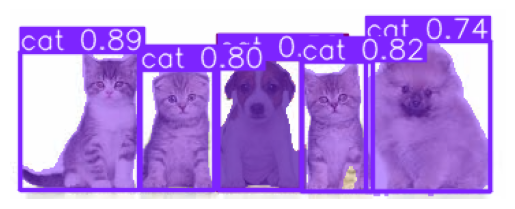

In [4]:
# 단 한장의 segmentation 결과를 res 변수에 저장
res = model(im_bgr, verbose=False)[0]

# Bounding Box, Label plot
annotated = res.plot()

# Segmentation 된 이미지 저장
cv2.imwrite(os.path.join(OUT_DIR, "yolo10segmentation_result.jpg"), annotated)

# 화면 시각화
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [13]:
# Pytorch의 Tensor를 Numpy 배열로 변환하는 작업
has_masks = (res.masks is not None)

if has_masks:
    masks_np = res.masks.data.cpu().numpy()
    boxes_np = res.boxes.xyxy.cpu().numpy().astype(int)
    conf_np = res.boxes.conf.cpu().numpy()
    class_np = res.boxes.cls.cpu().numpy().astype(int)
else:
    masks_np = boxes_np = conf_np = class_np = None


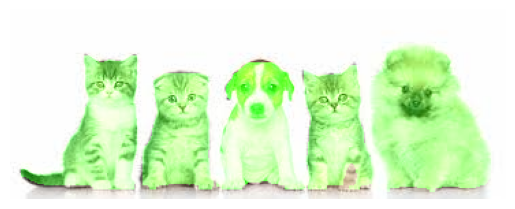

In [ ]:
# 마스크 오버레이
overlay = im_bgr.copy()

'''
# Semantic segmentation : Object segmentation을 하되 같은 class인 object들은 같은 영역 혹은 색으로 분할하는 것
# Instance segmentation : 같은 class이여도 서로 다른 instance로 구분해주는 것
'''

# Instance segmentation : 같은 class이여도 서로 다른 instance로 구분해주는 것
if has_masks:
    for m in masks_np:
        # 모델이 출력한 마스크 크기를 원본 크기로 resize (단, 0.5 이상일 때만 객체로 간주)
        m_bin = cv2.resize(m, (Width, Height), interpolation=cv2.INTER_NEAREST) > 0.5
        # print(m_bin)

        # 원본 이미지와 동일한 크기의 bin(0으로 채워진 -->> 검정색) 배열 생성
        color_mask = np.zeros_like(overlay)

        # m_bin이 True인 값에만 색깔을(초록색=(0, 255, 0)) 입힘
        color_mask[m_bin] = (0, 255, 0)

        # 가중치를 고려한 이미지 합성 : 0으로 검게 칠한 바탕 이미지 + 초록색으로 색칠한 mask 부분 이미지
        # cv2.addWeighted("이미지1", 비율1, "이미지2", 비율2, 추가 밝기 조정)
        overlay = cv2.addWeighted(overlay, 1.0, color_mask, 0.4, 0.0)

cv2.imwrite(os.path.join(OUT_DIR, "yolo10_instance_segmentation_overlay.jpeg"), overlay)

# 화면 시각화
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [34]:
# 객체별 배경제거 후, PNG로 각 객체 따로 저장
crops_dir = os.path.join(OUT_DIR, "seg_crops")
os.makedirs(crops_dir, exist_ok=True)

# YOLO 출력 마스크를 원본 이미지 크기에 맞게 변환 후 여러 객체 마스크 처리
if has_masks and len(masks_np) > 0:
    # 2진 데이터로 만들어서, stack
    masks_full = np.stack(
        [cv2.resize(m, (Width, Height), interpolation=cv2.INTER_NEAREST) > 0.5 for m in masks_np],
        axis=0
    )

    # 탐지된 객체의 배경을 제거해, PNG로 저장
    for i, (m_full, box, cls_id, conf) in enumerate(zip(masks_full, boxes_np, class_np, conf_np)):
        
        # box 꼭짓점 mapping
        x1, y1, x2, y2 = map(int, box)

        # Bounding box 꼭짓점 외부 배경 처리
        x1, y1 = max(0, x1), max(0, y1)     # 좌상단 좌표가 이미지 밖으로 나가면 검정색으로 칠함(0으로 보정)
        x2, y2 = min(Width, x2), min(Height, y2)     # 우하단 좌표가 이미지 밖으로 나가면 검정색으로 칠함(0으로 보정)

        # 잘못된 바운딩 박스 좌표는 건너뜀
        if x2 <= x1 or y2 <= y1:
            continue
        
        # openCV는 배열 순서가 [Height, Width, canel] 로 구성.  -->>    이미지 자를 때, 주의해야함
        crop_bgr = im_bgr[y1:y2, x1:x2]

        # 같은 영역 mask를 불투명하게 변환
        crop_mask = (m_full[y1:y2, x1:x2] * 255).astype(np.uint8)

        # 불투명도 alpha 채널 추가(BRG2BGRA)
        crop_bgra = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2BGRA)

        # 앞 차원(BGR)은 그대로 두고, 네번째(불투명도 alpha channel)채널에 mask 적용
        # 배경은 투명, 객체는 불투명
        crop_bgra[..., 3] = crop_mask

        # 클래스 이름 얻기 (dog, cat, ...)
        # model에 names가 있으면 클래스 이름(dog, cat 등)을 가져오고 없으면 cls_id 숫자를 문자열로 사용한다.
        # hasatrr : 객체가 특정 속성을 가지고 있는지 확인하는 함수, 결과는 True 또는 False
        name = model.names[int(cls_id)] if hasattr(model, "names") else str(cls_id)
        
        cv2.imwrite(os.path.join(crops_dir, f"crop{i}_{name}_{conf:.2f}.png"), crop_bgra)

In [38]:
# Semantic segmentation
# 같은 class에 속한 객체들은 같은 색으로 칠해서 표현하는 방식

# 결과를 그릴 빈 이미지 생성
# 원본 이미지와 같은 크기의 검정색 캔버스를 만든다
sem_canvas = np.zeros((Height, Width, 3), dtype=np.uint8)

# 픽셀별 신뢰도 저장용 지도 생성
# 각 픽셀에 어떤 객체의 confidence가 가장 높은지 기록한다
conf_map = np.zeros((Height, Width), dtype=np.float32)

# 클래스별 색상 생성 함수
# class id마다 항상 같은 BGR 색상이 나오도록 만든다
def class_color(c:int):
    return ((35 * c) % 256, (17 * c) % 256, (91 * c) % 256)

# 마스크가 존재할 때만 semantic segmentation 수행
# 탐지된 마스크가 1개 이상 있을 경우 실행한다
if has_masks and len(masks_np) > 0:

    # 각 객체의 마스크, 클래스 id, 신뢰도를 하나씩 꺼낸다
    for m_full, cls_id, conf in zip(masks_full, class_np, conf_np):

        # 현재 객체의 class id에 맞는 색상을 가져온다
        color = class_color(int(cls_id))

        # 현재 객체가 차지하는 영역 중,
        # 기존보다 confidence가 더 높은 픽셀만 선택한다
        # update : 이번에 새로 칠할 픽셀 위치
        update = m_full & (conf > conf_map)

        # 선택된 픽셀 위치에 class 색상을 칠한다
        sem_canvas[update] = color

        # 선택된 픽셀 위치의 confidence 값을 현재 객체 confidence로 갱신한다
        conf_map[update] = conf

cv2.imwrite(os.path.join(OUT_DIR, "yolo10seg_Semantic.jpeg"), sem_canvas)

True